In [1]:
import polars as pl
import numpy as np
import pickle

from data_valuation.core.loo_valuator import LOOValuator
from data_valuation.core.shapley_valuator import ShapleyValuator
from data_valuation.core.dvrl_valuator import DVRLValuator

from dvrl.sampling import select_diverse_subset
from dvrl.dataset import EssayDataset

/home/ito/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROMPT_ID = 1
RANDOM_SEED = 12

In [4]:
# Load embedding
with open('../outputs/embedding/deberta-v3-large.pkl', 'rb') as f:
    embedding_dict = pickle.load(f)

# Load essay data
print('Loading essay data...')
dataset = EssayDataset('../data/training_set_rel3.xlsx', '../data/hand_crafted_v3.csv', '../data/readability_features.csv')
source_data, target_data = dataset.cross_prompt_split(
    target_prompt_set=PROMPT_ID,
    add_pos=False,
)
print(f'    Number of source samples: {len(source_data["essay_id"])}')
print(f'    Number of target samples: {len(target_data["essay_id"])}')

# Select dev data
selected_dev_ids = select_diverse_subset(
    {essay_id: embedding_dict[essay_id] for essay_id in target_data['essay_id'] if essay_id in embedding_dict},
    n_samples=30,
    method='random',
    seed=RANDOM_SEED,
)
dev_mask = np.isin(target_data['essay_id'], selected_dev_ids)

x_dev = target_data['essay'][dev_mask]
y_dev = target_data['scaled_score'][dev_mask]

Loading essay data...
    Number of source samples: 11194
    Number of target samples: 1783


In [5]:
def add_noise(data: pl.DataFrame, noise_ratio: float, noise_range: tuple, seed: int) -> pl.DataFrame:
    np.random.seed(seed)
    noise_indices = np.random.choice(data.shape[0], int(data.shape[0] * noise_ratio), replace=False)
    noise_signs = np.random.choice([-1, 1], len(noise_indices))
    noise = np.random.uniform(noise_range[0], noise_range[1], len(noise_indices))

    noisy_scores = data['scaled_score'].to_numpy().copy()
    noisy_scores[noise_indices] += noise_signs * noise
    noisy_scores = np.clip(noisy_scores, 0, 1)  # Clipping

    data = data.with_columns(pl.Series(noisy_scores).alias('noisy_score'))

    is_noisy = np.zeros(data.shape[0], dtype=bool)
    is_noisy[noise_indices] = True
    data = data.with_columns(pl.Series(is_noisy).alias('is_noisy'))
    return data

train_data = add_noise(pl.DataFrame(source_data), noise_ratio=0.2, noise_range=(0.4, 0.6), seed=RANDOM_SEED)
train_data = train_data.drop(['ridley_feature', 'feature', 'readability'])
train_data.write_csv(f'../outputs/noise_detection/train_data_ds_{PROMPT_ID}.csv')
train_data

essay_id,essay_set,essay,original_score,scaled_score,noisy_score,is_noisy
i64,i64,str,i64,f64,f64,bool
2978,2,"""Certain materials being remove…",4,0.6,0.6,false
2979,2,"""Write a persuasive essay to a …",1,0.0,0.0,false
2980,2,"""Do you think that libraries sh…",2,0.2,0.2,false
2981,2,"""In @DATE1's world, there are m…",4,0.6,0.6,false
2982,2,"""In life you have the 'offensiv…",4,0.6,0.6,false
…,…,…,…,…,…,…
21626,8,""" In most stories mothers and d…",35,0.583333,0.583333,false
21628,8,""" I never understood the meanin…",32,0.533333,0.533333,false
21629,8,"""When you laugh, is @CAPS5 out …",40,0.666667,1.0,true


In [5]:
# # Leave-One-Out Valuation
# valuator = LOOValuator(
#     prompt_id=PROMPT_ID,
#     device='cuda',
#     seed=RANDOM_SEED,
# )

# # Data Shapley Valuation
# valuator = ShapleyValuator(
#     prompt_id=PROMPT_ID,
#     device='cuda',
#     seed=RANDOM_SEED,
# )

# Data Valuation with Reinforcement Learning (DVRL)
valuator = DVRLValuator(
    prompt_id=PROMPT_ID,
    device='cuda',
    seed=RANDOM_SEED,
)


=== DVRLValuator Hyperparameters ===
Prompt ID: 1
Device: cuda
Seed: 12
Metric: qwk
Embedding Model: microsoft/deberta-v3-large
Max Length: 512
Pooling Strategy: cls
Hidden Dimension: 100
Combination Dimension: 10
Iterations: 1000
Inner Iterations: 100
Batch Size: 10000
Learning Rate: 0.001
Predictor Batch Size: 512
Model Type: mlp
Epsilon: 1e-08
Threshold: 0.9



In [6]:
estimated_values = valuator.estimate_values(
    x_train=train_data['essay'].to_list(),
    y_train=train_data['noisy_score'].to_numpy(),
    x_val=x_dev.tolist(),
    y_val=y_dev,
    sample_ids=train_data['essay_id'].to_numpy(),
)

# Save the estimated values
valuator.save_values(estimated_values, f'../outputs/noise_detection/estimated_values_ds_{PROMPT_ID}.csv')

/home/ito/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
2025-05-21 18:11:17.624572: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 18:11:17.625822: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-21 18:11:17.647100: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performan

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Iteration 77
Iteratio

In [6]:
# Load the estimated values as DataFrame
value_df = pl.read_csv(f'../outputs/noise_detection/estimated_values_loo_{PROMPT_ID}.csv').rename({'sample_id': 'essay_id'})
train_data = train_data.join(value_df, on='essay_id', how='left')
train_data

essay_id,essay_set,essay,original_score,scaled_score,noisy_score,is_noisy,value
i64,i64,str,i64,f64,f64,bool,f64
2978,2,"""Certain materials being remove…",4,0.6,0.6,false,-0.00278
2979,2,"""Write a persuasive essay to a …",1,0.0,0.0,false,0.002627
2980,2,"""Do you think that libraries sh…",2,0.2,0.2,false,0.005558
2981,2,"""In @DATE1's world, there are m…",4,0.6,0.6,false,0.004528
2982,2,"""In life you have the 'offensiv…",4,0.6,0.6,false,0.000875
…,…,…,…,…,…,…,…
21626,8,""" In most stories mothers and d…",35,0.583333,0.583333,false,0.001737
21628,8,""" I never understood the meanin…",32,0.533333,0.533333,false,0.015542
21629,8,"""When you laugh, is @CAPS5 out …",40,0.666667,1.0,true,0.009052


array([0.05227882, 0.10768543, 0.15281501, 0.20420018, 0.25692583,
       0.30428954, 0.34807864, 0.39588919, 0.45174263, 0.50357462,
       0.55004468, 0.59159964, 0.64879357, 0.69928508, 0.75067024,
       0.79133155, 0.84763181, 0.9025916 , 0.95487042, 1.        ])

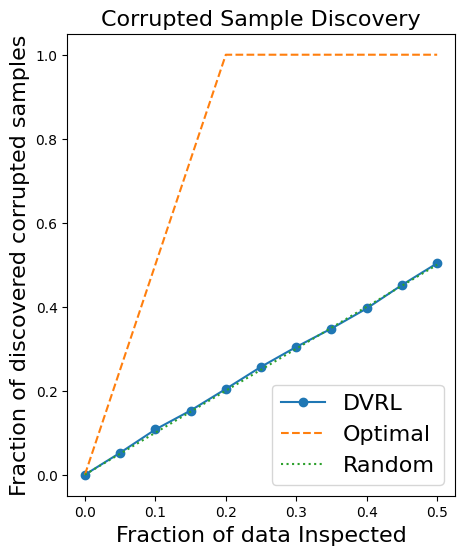

In [7]:
import matplotlib.pyplot as plt

def discover_corrupted_sample(dve_out, noise_mask, noise_rate, output_path=None, plot=True):
  """Reports True Positive Rate (TPR) of corrupted label discovery.

  Args:
    dve_out: data values (numpy array)
    noise_mask: 各サンプルがノイズか否かを示す True/False のブール配列
    noise_rate: ノイズサンプルの割合
    output_path: プロット画像の出力先パス
    plot: プロットを表示するかどうか

  Returns:
    output_perf: パーセンタイル毎（例: 5%刻み）に算出したノイズ検出率（TPR）
  """

  # サンプルをデータ値でソート
  num_bins = 20  # 100%を20分割
  sort_idx = np.argsort(dve_out)

  # 出力用初期化
  output_perf = np.zeros([num_bins,])
  total_noise = np.sum(noise_mask)  # 全ノイズサンプル数

  # 各パーセンタイルごとに計算
  for itt in range(num_bins):
    num_samples = int((itt+1) * len(dve_out) / num_bins)
    # 現在の範囲内でのノイズサンプル数をカウント
    discovered_noise = np.sum(noise_mask[sort_idx[:num_samples]])
    output_perf[itt] = discovered_noise / total_noise

  # ノイズ検出率のグラフをプロット
  if plot:
    num_x = int(num_bins / 2 + 1)
    x = [a * (1.0 / num_bins) for a in range(num_x)]
    y_dvrl = np.concatenate((np.zeros(1), output_perf[:(num_x - 1)]))
    y_opt = [min(a * ((1.0 / num_bins) / noise_rate), 1) for a in range(num_x)]
    y_random = x

    plt.figure(figsize=(5, 6))
    plt.plot(x, y_dvrl, 'o-')
    plt.plot(x, y_opt, '--')
    plt.plot(x, y_random, ':')
    plt.xlabel('Fraction of data Inspected', size=16)
    plt.ylabel('Fraction of discovered corrupted samples', size=16)
    plt.legend(['DVRL', 'Optimal', 'Random'], prop={'size': 16})
    plt.title('Corrupted Sample Discovery', size=16)
    if output_path:
      plt.savefig(output_path + 'corrupted_sample_discovery.pdf')

  # ノイズ検出率 (TPR) を返す
  return output_perf

# Assuming 'value' column contains the data values
dve_out = train_data['value'].to_numpy()
# Assuming 'is_noisy' column indicates corrupted samples (True for corrupted)
noise_mask = train_data['is_noisy'].to_numpy()
noise_rate = train_data['is_noisy'].mean()  # Calculate the noise rate

# Call the function and plot
# discover_corrupted_sample(dve_out, noise_mask, noise_rate, output_path='../outputs/noise_detection/')
discover_corrupted_sample(dve_out, noise_mask, noise_rate)

# Plots for paper

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # 忘れずにインポート

def discover_corrupted_sample_multi(dve_out_list, labels, noise_mask, noise_rate, output_path=None, plot=True):
    """
    複数の data value 推定結果に対してノイズ検出率 (TPR) をプロットします。
    """

    assert len(dve_out_list) == len(labels), "dve_out_listとlabelsの長さが一致していません"

    # sns.set_theme(style="whitegrid", font_scale=1.4)

    num_bins = 20
    total_noise = np.sum(noise_mask)
    num_x = int(num_bins / 2 + 1)
    x = [a * (1.0 / num_bins) for a in range(num_x)]

    perf_dict = {}
    fig, ax = plt.subplots(figsize=(8, 6))

    # スタイル定義（必要に応じて拡張可能）
    style_map = {
        "DVRL":      {'marker': 'o', 'linestyle': '-',  'color': '#1f77b4', 'zorder': 5},
        "Data Shapley": {'marker': 's', 'linestyle': '--', 'color': '#ff7f0e', 'zorder': 4},
        "LOO":       {'marker': 'D', 'linestyle': ':',  'color': '#2ca02c', 'zorder': 3},
    }

    for dve_out, label in zip(dve_out_list, labels):
        sort_idx = np.argsort(dve_out)
        output_perf = np.zeros([num_bins,])

        for itt in range(num_bins):
            num_samples = int((itt+1) * len(dve_out) / num_bins)
            discovered_noise = np.sum(noise_mask[sort_idx[:num_samples]])
            output_perf[itt] = discovered_noise / total_noise

        y = np.concatenate((np.zeros(1), output_perf[:(num_x - 1)]))
        style = style_map.get(label, {'marker': 'o', 'linestyle': '-', 'color': None, 'zorder': 3})

        ax.plot(
            x, y,
            label=label,
            marker=style['marker'],
            linestyle=style['linestyle'],
            linewidth=2,
            markersize=10,
            color=style['color'],
            zorder=style['zorder']
        )
        perf_dict[label] = output_perf

    # ベースライン
    y_opt = [min(a * ((1.0 / num_bins) / noise_rate), 1) for a in range(num_x)]
    y_random = x
    ax.plot(x, y_opt, linestyle='--', linewidth=2, color='gray', label='Optimal', zorder=2)
    ax.plot(x, y_random, linestyle=':', linewidth=2, color='black', label='Random', zorder=1)

    # 軸・凡例など書式
    ax.set_xlabel('Fraction of data inspected', fontsize=16)
    ax.set_ylabel('Fraction of discovered corrupted samples', fontsize=16)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.tick_params(axis='both', labelsize=14)

    # 凡例順を明示的に指定
    legend_order = ['DVRL', 'Data Shapley', 'LOO', 'Optimal', 'Random']
    handles, labels_ = ax.get_legend_handles_labels()
    ordered_handles = [h for l in legend_order for h, lbl in zip(handles, labels_) if lbl == l]
    ax.legend(ordered_handles, legend_order, fontsize=16, loc='lower right')

    plt.tight_layout()
    if output_path:
        fig.savefig(output_path + 'corrupted_sample_discovery_multi.pdf', bbox_inches='tight', dpi=300)
    if plot:
        plt.show()

    return perf_dict

In [7]:
# Load the estimated values as DataFrame
value_df_dvrl = pl.read_csv(f'../outputs/noise_detection/estimated_values_dvrl_{PROMPT_ID}.csv').rename({'sample_id': 'essay_id'})
value_df_ds = pl.read_csv(f'../outputs/noise_detection/estimated_values_ds_{PROMPT_ID}.csv').rename({'sample_id': 'essay_id'})
value_df_loo = pl.read_csv(f'../outputs/noise_detection/estimated_values_loo_{PROMPT_ID}.csv').rename({'sample_id': 'essay_id'})
train_data = pl.read_csv(f'../outputs/noise_detection/train_data_dvrl_{PROMPT_ID}.csv')

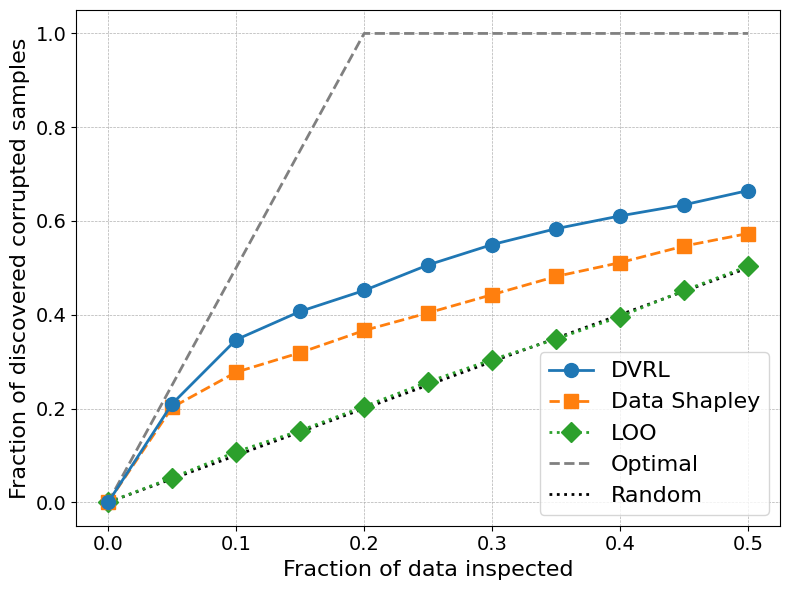

{'DVRL': array([0.21000894, 0.34673816, 0.40705987, 0.45174263, 0.50625559,
        0.54959786, 0.58355675, 0.61081323, 0.63449508, 0.66487936,
        0.70017873, 0.72743521, 0.74754245, 0.75915996, 0.78328865,
        0.81099196, 0.83646113, 0.88203753, 0.93923146, 1.        ]),
 'Data Shapley': array([0.20241287, 0.27747989, 0.31903485, 0.36639857, 0.40393208,
        0.44280608, 0.48168007, 0.51117069, 0.54647006, 0.57327971,
        0.59830206, 0.61840929, 0.63404826, 0.64387846, 0.65817694,
        0.67739053, 0.71894549, 0.79892761, 0.88248436, 1.        ]),
 'LOO': array([0.05227882, 0.10768543, 0.15281501, 0.20420018, 0.25692583,
        0.30428954, 0.34807864, 0.39588919, 0.45174263, 0.50357462,
        0.55004468, 0.59159964, 0.64879357, 0.69928508, 0.75067024,
        0.79133155, 0.84763181, 0.9025916 , 0.95487042, 1.        ])}

In [8]:
# 例: 複数のdve_outがある場合
dve_out_1 = value_df_dvrl['value'].to_numpy()
dve_out_2 = value_df_ds['value'].to_numpy()
dve_out_3 = value_df_loo['value'].to_numpy()

noise_mask = train_data['is_noisy'].to_numpy()
noise_rate = train_data['is_noisy'].mean()

discover_corrupted_sample_multi(
    dve_out_list=[dve_out_1, dve_out_2, dve_out_3],
    labels=['DVRL', 'Data Shapley', 'LOO'],
    noise_mask=noise_mask,
    noise_rate=noise_rate,
    # output_path=None,  # '../outputs/noise_detection/'
    output_path='../outputs/noise_detection/',
    plot=True
)